In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_profiling as pp
%matplotlib inline

In [2]:
from sklearn.preprocessing import StandardScaler

In [3]:
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error
from math import sqrt

In [4]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [5]:
df=pd.read_csv('final_dataset.csv')
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,view,sqft_above,lat,long,sqft_living15,sqft_lot15,houseage,has_underground,has_renovated
0,221900,3,1,1180,5650,1,0,1180,47.51120,-122.25700,1340,5650,59,0,0
1,538000,3,2,2570,7242,2,0,2170,47.72100,-122.31900,1690,7639,63,1,1
2,180000,2,1,770,10000,1,0,770,47.73790,-122.23300,2720,8062,82,0,0
3,604000,4,3,1960,5000,1,0,1050,47.52080,-122.39300,1360,5000,49,1,0
4,510000,3,2,1680,8080,1,0,1680,47.61680,-122.04500,1800,7503,28,0,0


In [6]:
df['view'].value_counts()

0    18192
2      788
3      373
1      300
4      226
Name: view, dtype: int64

In [7]:
df.corr()['price']

price              1.00000
bedrooms           0.27806
bathrooms          0.39315
sqft_living        0.61603
sqft_lot           0.09087
floors             0.21440
view               0.36239
sqft_above         0.49518
lat                0.38733
long              -0.01400
sqft_living15      0.54415
sqft_lot15         0.08647
houseage           0.00273
has_underground    0.20225
has_renovated      0.13683
Name: price, dtype: float64

In [8]:
X = df.drop(['price','sqft_living15','sqft_lot15','houseage'], axis=1)
y = df['price']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

##### linear regression

In [10]:
linear_model = LinearRegression()

In [11]:
linear_model.fit(X_train, y_train)

LinearRegression()

In [12]:
linear_predictions = linear_model.predict(X_test)

In [13]:
linear_score = explained_variance_score(y_test, linear_predictions)
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = sqrt(mean_squared_error(y_test, linear_predictions))

print("Linear Regression Score: {:.4f}".format(linear_score))
print("Linear Regression MAE: {:.4f}".format(linear_mae))
print("Linear Regression RMSE: {:.4f}".format(linear_rmse))


Linear Regression Score: 0.5783
Linear Regression MAE: 118380.3246
Linear Regression RMSE: 173973.8761


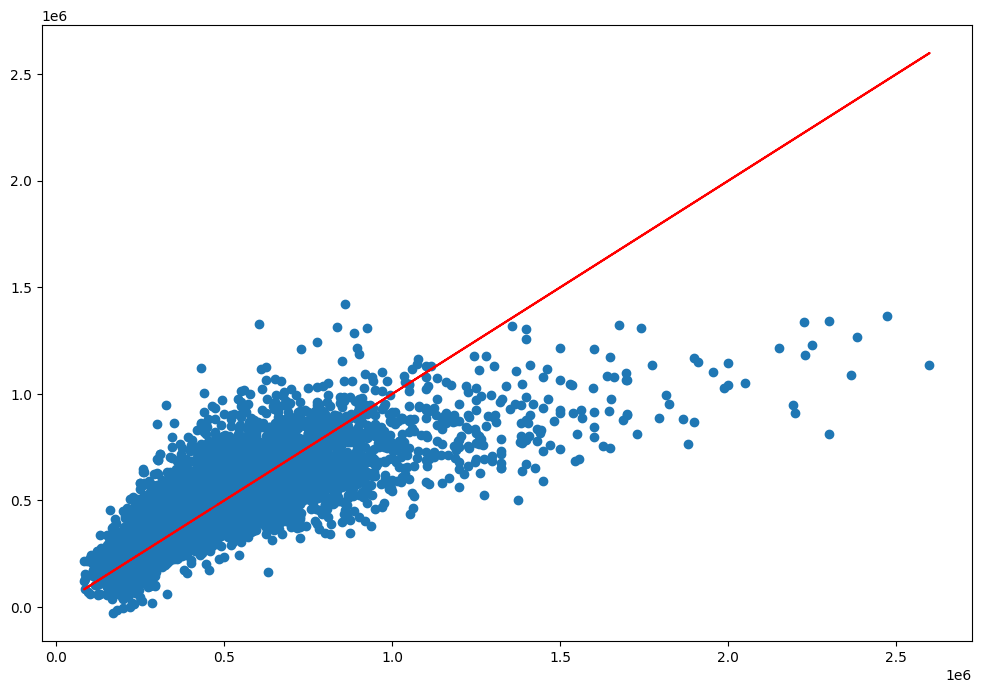

In [14]:
plt.figure(figsize=(12, 8))
plt.scatter(y_test, linear_predictions)
plt.plot(y_test, y_test, color='r')


##### standardiazation + linear regression

In [15]:
std=StandardScaler()
X_train_std=std.fit_transform(X_train)
X_test_std=std.transform(X_test)

In [16]:
linear_model = LinearRegression()

In [17]:
linear_model.fit(X_train_std, y_train)

LinearRegression()

In [18]:
linear_predictions = linear_model.predict(X_test_std)

In [19]:
linear_score = explained_variance_score(y_test, linear_predictions)
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = sqrt(mean_squared_error(y_test, linear_predictions))

print("Linear Regression Score: {:.4f}".format(linear_score))
print("Linear Regression MAE: {:.4f}".format(linear_mae))
print("Linear Regression RMSE: {:.4f}".format(linear_rmse))

Linear Regression Score: 0.5783
Linear Regression MAE: 118380.3246
Linear Regression RMSE: 173973.8761


##### random forest regression

In [20]:
X = df.drop(['price','sqft_living15','sqft_lot15','houseage'],axis=1)
y = df['price'].values

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [22]:
regressor = RandomForestRegressor(n_estimators = 100, random_state = 0)

In [23]:
regressor.fit(X_train, y_train)

RandomForestRegressor(random_state=0)

In [24]:
X.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'view',
       'sqft_above', 'lat', 'long', 'has_underground', 'has_renovated'],
      dtype='object')

##### self defined input values using random forest regressor


In [25]:
features = np.array([[2,2,1000,2000,2,3,1180,47.51120,-122.25700,0,0]])

In [26]:
regressor.predict(features)

C:\Users\nepal\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([371573.5])

##### testing set values

In [27]:
rand_forest_predictions = regressor.predict(X_test)

In [28]:
regressor.score(X_test,y_test)

0.8456516440071236

In [29]:
rand_forest_score = explained_variance_score(y_test, rand_forest_predictions)
rand_forest_mae = mean_absolute_error(y_test, rand_forest_predictions)
rand_forest_rmse = sqrt(mean_squared_error(y_test, rand_forest_predictions))

print("Random Forest Score: {:.4f}".format(rand_forest_score))
print("Random Forest MAE: {:.4f}".format(rand_forest_mae))
print("Random Forest RMSE: {:.4f}\n".format(rand_forest_rmse))

Random Forest Score: 0.8457
Random Forest MAE: 64053.8332
Random Forest RMSE: 105254.1707



### MAE 
##### takes the average sum of the absolute differences between the actual and the predicted values. For a data point xi and its predicted value yi, n being the total number of data points in the dataset, the mean absolute error is defined as:

##### MAE
##### 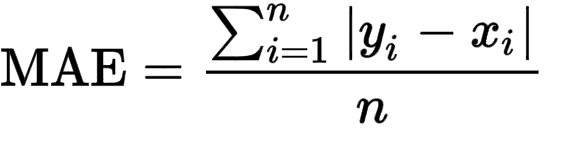

In [34]:
import pickle

In [35]:
pickle.dump(regressor, open('model.pkl', 'wb'))

In [32]:
# model=pickle.load(open('model.pkl','rb'))